# КИМ 2.1. Backprop и обучение сети — эталонное решение

> **Это эталонное решение** для преподавателя. Студентам выдаётся ноутбук-задание
> [`kim-02-backprop-training.ipynb`](./kim-02-backprop-training.ipynb) без заполненных ячеек.
>
> Код ниже — один из возможных вариантов решения; не единственный и не обязательно
> оптимальный. Приводится для сверки и подготовки к защите.

В этом эталоне:
- **Часть А** — backprop вручную на чистом NumPy;
- **Части Б и В** — та же задача на PyTorch с автодифференцированием.

Fashion-MNIST загружается один раз через `torchvision`, после чего часть А работает
только с массивами NumPy.

---
## Часть А. Backprop на чистом NumPy (обязательно)

Архитектура: $784 \rightarrow 64\ (\mathrm{ReLU}) \rightarrow 10\ (\mathrm{softmax})$.
Все производные и обновления параметров в этой части реализованы вручную, без
автодифференцирования.

### 0. Импорт и подмножество Fashion-MNIST

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
%matplotlib inline

SEED = 42
np.random.seed(SEED)

# torchvision хранит изображения и метки как torch.Tensor. Для ручной части
# сразу извлекаем NumPy-массивы и больше не используем операции PyTorch.
fashion_train = datasets.FashionMNIST(root='./data', train=True, download=True)
x_full = fashion_train.data.numpy().astype(np.float32) / 255.0
y_full = fashion_train.targets.numpy()

N = 10_000
subset_idx = np.random.choice(len(x_full), N, replace=False)
X = x_full[subset_idx].reshape(N, 784)
labels = y_full[subset_idx]
y = np.eye(10, dtype=np.float32)[labels]

split = int(0.8 * N)
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]
y_train_idx, y_val_idx = labels[:split], labels[split:]
print(X_train.shape, y_train.shape, X_val.shape, y_val.shape)

  0%|          | 0.00/26.4M [00:00<?, ?B/s]

  0%|          | 32.8k/26.4M [00:00<02:08, 206kB/s]

  0%|          | 131k/26.4M [00:00<01:02, 423kB/s] 

  2%|▏         | 426k/26.4M [00:00<00:22, 1.14MB/s]

  3%|▎         | 885k/26.4M [00:00<00:12, 1.99MB/s]

...

Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



  0%|          | 0.00/5.15k [00:00<?, ?B/s]

100%|██████████| 5.15k/5.15k [00:00<00:00, 14.3MB/s]

Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



(8000, 784) (8000, 10) (2000, 784) (2000, 10)


### 1. Инициализация параметров (He для ReLU)

In [2]:
def init_params():
    W1 = (np.random.randn(784, 64) * np.sqrt(2.0 / 784)).astype(np.float32)
    b1 = np.zeros(64, dtype=np.float32)
    W2 = (np.random.randn(64, 10) * np.sqrt(2.0 / 64)).astype(np.float32)
    b2 = np.zeros(10, dtype=np.float32)
    return W1, b1, W2, b2

W1, b1, W2, b2 = init_params()

### 2. Прямой проход

In [3]:
def relu(z):
    return np.maximum(0, z)

def softmax(z):
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def forward(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1        # (B, 64)
    a1 = relu(z1)           # (B, 64)
    z2 = a1 @ W2 + b2       # (B, 10)
    y_hat = softmax(z2)     # (B, 10)
    return z1, a1, z2, y_hat

### 3. Функция потерь — кросс-энтропия

In [4]:
def cross_entropy(y_hat, y):
    eps = 1e-12
    return -np.sum(y * np.log(y_hat + eps)) / len(y)

### 4. Обратный проход

Для softmax и cross-entropy совместная производная по логитам равна
$\partial L / \partial z_2 = (\hat{y} - y) / B$. Затем градиент передаётся
назад через второй линейный слой и ReLU.

In [5]:
def backward(X, y, z1, a1, y_hat, W2):
    B = len(X)
    dz2 = (y_hat - y) / B                   # (B, 10)
    dW2 = a1.T @ dz2                        # (64, 10)
    db2 = np.sum(dz2, axis=0)               # (10,)
    da1 = dz2 @ W2.T                        # (B, 64)
    dz1 = da1 * (z1 > 0)                    # производная ReLU
    dW1 = X.T @ dz1                         # (784, 64)
    db1 = np.sum(dz1, axis=0)               # (64,)
    return dW1, db1, dW2, db2

### 5. Обучение ручной сети

In [6]:
def iterate_minibatches(X, y, batch_size, shuffle=True):
    indices = np.random.permutation(len(X)) if shuffle else np.arange(len(X))
    for start in range(0, len(X), batch_size):
        batch_indices = indices[start:start + batch_size]
        yield X[batch_indices], y[batch_indices]

lr = 0.1
epochs = 30
batch_size = 64
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    for xb, yb in iterate_minibatches(X_train, y_train, batch_size):
        z1, a1, z2, y_hat = forward(xb, W1, b1, W2, b2)
        dW1, db1, dW2, db2 = backward(xb, yb, z1, a1, y_hat, W2)

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    _, _, _, train_prob = forward(X_train, W1, b1, W2, b2)
    _, _, _, val_prob = forward(X_val, W1, b1, W2, b2)
    train_losses.append(cross_entropy(train_prob, y_train))
    val_losses.append(cross_entropy(val_prob, y_val))
    train_accs.append(np.mean(train_prob.argmax(axis=1) == y_train_idx))
    val_accs.append(np.mean(val_prob.argmax(axis=1) == y_val_idx))

    if (epoch + 1) % 5 == 0:
        print(f'Эпоха {epoch + 1:2d}: train_loss={train_losses[-1]:.4f}  '
              f'val_loss={val_losses[-1]:.4f}  val_acc={val_accs[-1]:.4f}')

print(f'Итоговая val_acc NumPy: {val_accs[-1]:.4f}')

Эпоха  5: train_loss=0.4526  val_loss=0.5014  val_acc=0.8335


Эпоха 10: train_loss=0.3877  val_loss=0.4630  val_acc=0.8315


Эпоха 15: train_loss=0.3152  val_loss=0.4274  val_acc=0.8510


Эпоха 20: train_loss=0.2960  val_loss=0.4337  val_acc=0.8550


Эпоха 25: train_loss=0.2581  val_loss=0.4155  val_acc=0.8555


Эпоха 30: train_loss=0.2290  val_loss=0.4168  val_acc=0.8625
Итоговая val_acc NumPy: 0.8625


При фиксированном seed итоговая `val_acc` обычно находится примерно в
диапазоне **0.83–0.85**. Небольшие отличия возможны между версиями NumPy и BLAS.

### 6. Кривые обучения

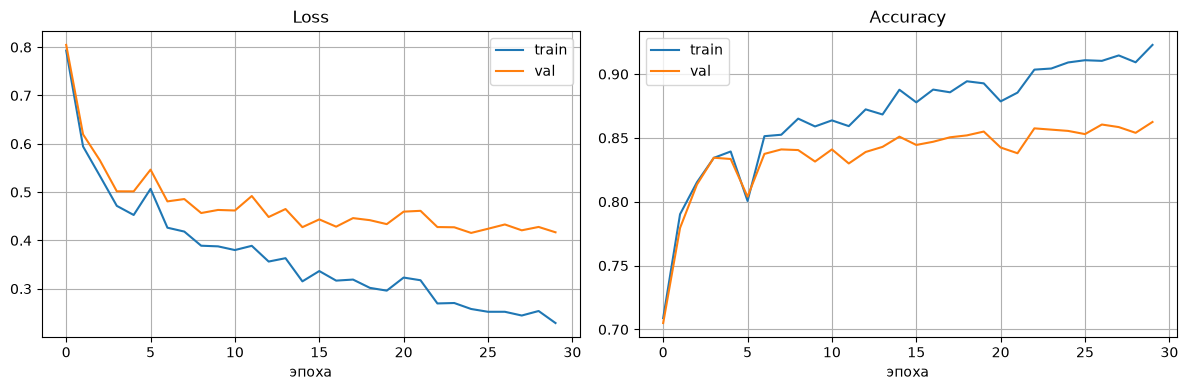

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(train_losses, label='train')
ax[0].plot(val_losses, label='val')
ax[0].set_title('Loss')
ax[1].plot(train_accs, label='train')
ax[1].plot(val_accs, label='val')
ax[1].set_title('Accuracy')
for a in ax:
    a.set_xlabel('эпоха')
    a.legend()
    a.grid(True)
plt.tight_layout()
plt.show()

**Правило цепи.** Для матричной записи с объектами в строках:
$dW_2 = a_1^T dz_2$, $da_1 = dz_2 W_2^T$,
$dz_1 = da_1 \odot \mathbb{1}[z_1 > 0]$ и $dW_1 = X^T dz_1$.
Именно эта последовательность реализована в `backward`; матрица `W2`, нужная для
передачи градиента, передаётся в функцию явно.

---
## Часть Б. Явный цикл обучения на PyTorch

PyTorch автоматически вычисляет градиенты, но сам цикл обучения остаётся явным.
Последний слой возвращает **сырые логиты**: `CrossEntropyLoss` сам применяет
численно устойчивый `log_softmax`, поэтому `Softmax` в модель добавлять нельзя.

### 7. Устройство, seed и тензоры

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
from torch.utils.data import DataLoader, TensorDataset

def set_torch_seed(seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_torch_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
print('Устройство:', device)

X_tr_t = torch.from_numpy(X_train).float()
y_tr_t = torch.from_numpy(y_train_idx).long()
X_va_t = torch.from_numpy(X_val).float()
y_va_t = torch.from_numpy(y_val_idx).long()
torch_train_ds = TensorDataset(X_tr_t, y_tr_t)

def make_loader(dataset, batch_size, seed=42):
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
        pin_memory=torch.cuda.is_available(),
    )

### Модель, оценка и пять шагов обучения

PyTorch: val_loss=0.4456, val_acc=0.8475


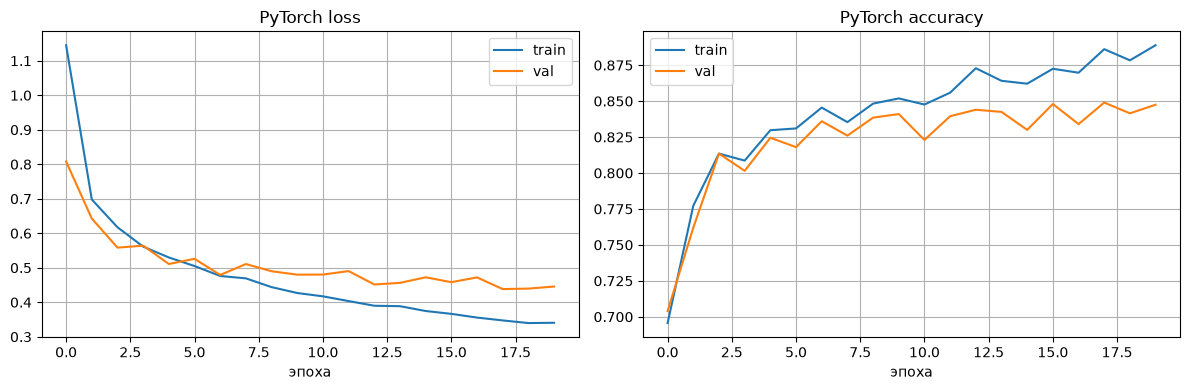

In [9]:
def make_model():
    return nn.Sequential(
        nn.Linear(784, 64),
        nn.ReLU(),
        nn.Linear(64, 10),
    )

def evaluate(model, X, y, criterion, device):
    model.eval()
    with torch.no_grad():
        X_device = X.to(device)
        y_device = y.to(device)
        logits = model(X_device)
        loss = criterion(logits, y_device).item()
        accuracy = (logits.argmax(dim=1) == y_device).float().mean().item()
    return loss, accuracy

def train_pytorch(model, loader, criterion, optimizer, device, epochs, X_val, y_val):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    X_train_eval, y_train_eval = loader.dataset.tensors

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad()             # 1. Обнулить старые градиенты
            logits = model(xb)                # 2. Прямой проход: сырые логиты
            loss = criterion(logits, yb)      # 3. Вычислить loss
            loss.backward()                   # 4. Обратный проход
            optimizer.step()                  # 5. Обновить параметры
            total_loss += loss.item() * len(xb)

        _, train_acc = evaluate(model, X_train_eval, y_train_eval, criterion, device)
        val_loss, val_acc = evaluate(model, X_val, y_val, criterion, device)
        history['train_loss'].append(total_loss / len(loader.dataset))
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

    return history

set_torch_seed(SEED)
model = make_model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)
train_loader = make_loader(torch_train_ds, batch_size=64, seed=SEED)
history = train_pytorch(
    model, train_loader, criterion, optimizer, device,
    epochs=20, X_val=X_va_t, y_val=y_va_t,
)

val_loss, val_acc = evaluate(model, X_va_t, y_va_t, criterion, device)
print(f'PyTorch: val_loss={val_loss:.4f}, val_acc={val_acc:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history['train_loss'], label='train')
ax[0].plot(history['val_loss'], label='val')
ax[0].set_title('PyTorch loss')
ax[1].plot(history['train_acc'], label='train')
ax[1].plot(history['val_acc'], label='val')
ax[1].set_title('PyTorch accuracy')
for a in ax:
    a.set_xlabel('эпоха')
    a.legend()
    a.grid(True)
plt.tight_layout()
plt.show()

### 8. Сравнение размеров пакета 10 / 50 / 200 / 500

batch_size= 10: val_loss=0.4513, val_acc=0.8505


batch_size= 50: val_loss=0.5112, val_acc=0.8320


batch_size=200: val_loss=0.5316, val_acc=0.8105


batch_size=500: val_loss=0.6302, val_acc=0.7960


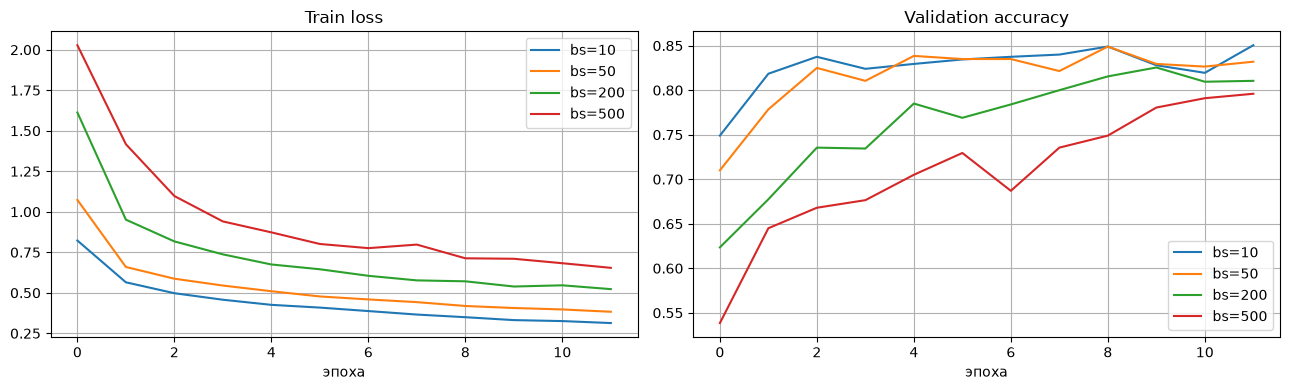

In [10]:
batch_sizes = [10, 50, 200, 500]
comparison = {}
comparison_epochs = 12

for batch_size in batch_sizes:
    # Одинаковый seed даёт моделям одинаковую начальную инициализацию.
    set_torch_seed(SEED)
    batch_model = make_model().to(device)
    batch_optimizer = optim.SGD(batch_model.parameters(), lr=0.1)
    batch_loader = make_loader(torch_train_ds, batch_size=batch_size, seed=SEED)
    batch_history = train_pytorch(
        batch_model, batch_loader, criterion, batch_optimizer, device,
        epochs=comparison_epochs, X_val=X_va_t, y_val=y_va_t,
    )
    comparison[batch_size] = batch_history
    print(f'batch_size={batch_size:3d}: '
          f'val_loss={batch_history["val_loss"][-1]:.4f}, '
          f'val_acc={batch_history["val_acc"][-1]:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for batch_size, batch_history in comparison.items():
    ax[0].plot(batch_history['train_loss'], label=f'bs={batch_size}')
    ax[1].plot(batch_history['val_acc'], label=f'bs={batch_size}')
ax[0].set_title('Train loss')
ax[1].set_title('Validation accuracy')
for a in ax:
    a.set_xlabel('эпоха')
    a.legend()
    a.grid(True)
plt.tight_layout()
plt.show()

**Вывод:** малые пакеты выполняют больше шумных обновлений за эпоху и
обычно быстрее улучшают метрики в пересчёте на эпохи. Большие пакеты дают более
гладкие, но более редкие обновления. Для сравнения времени нужно также учитывать,
что эпоха с `batch_size=10` содержит намного больше шагов оптимизатора.

### 9. Выбор активации, инициализации и связности

Сравниваем три конфигурации при одинаковых seed, optimizer, batch size и числе
эпох. Инициализация выбирается согласованно с активацией: He для ReLU, Xavier
для tanh. Число скрытых слоёв задаёт различную степень связности модели.

In [ ]:
class ConfigurableMLP(nn.Module):
    def __init__(self, hidden_sizes, activation):
        super().__init__()
        activation_factory = nn.ReLU if activation == 'relu' else nn.Tanh
        layers = []
        in_features = 784
        for hidden_size in hidden_sizes:
            linear = nn.Linear(in_features, hidden_size)
            if activation == 'relu':
                nn.init.kaiming_normal_(linear.weight, nonlinearity='relu')
            else:
                nn.init.xavier_normal_(linear.weight)
            nn.init.zeros_(linear.bias)
            layers.extend([linear, activation_factory()])
            in_features = hidden_size
        output = nn.Linear(in_features, 10)
        nn.init.xavier_normal_(output.weight)
        nn.init.zeros_(output.bias)
        layers.append(output)
        self.network = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.network(inputs)


configuration_specs = [
    ('ReLU + He, 1 слой', [64], 'relu'),
    ('tanh + Xavier, 1 слой', [64], 'tanh'),
    ('ReLU + He, 2 слоя', [128, 64], 'relu'),
]
configuration_results = []
configuration_ds = TensorDataset(X_tr_t[:4_000], y_tr_t[:4_000])

for name, hidden_sizes, activation in configuration_specs:
    set_torch_seed(SEED)
    configuration_model = ConfigurableMLP(hidden_sizes, activation).to(device)
    configuration_loader = make_loader(configuration_ds, batch_size=64, seed=SEED)
    configuration_optimizer = optim.SGD(configuration_model.parameters(), lr=0.05)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    started = time.perf_counter()
    configuration_history = train_pytorch(
        configuration_model, configuration_loader, criterion,
        configuration_optimizer, device, epochs=6, X_val=X_va_t, y_val=y_va_t,
    )
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - started
    parameters = sum(p.numel() for p in configuration_model.parameters())
    configuration_results.append({
        'конфигурация': name,
        'val_loss': configuration_history['val_loss'][-1],
        'val_accuracy': configuration_history['val_acc'][-1],
        'параметры': parameters,
        'секунды': elapsed,
    })

print(f"{'Конфигурация':<28} {'val loss':>10} {'val acc':>10} "
      f"{'параметры':>12} {'секунды':>9}")
for row in configuration_results:
    print(f"{row['конфигурация']:<28} {row['val_loss']:>10.4f} "
          f"{row['val_accuracy']:>10.4f} {row['параметры']:>12,} "
          f"{row['секунды']:>9.2f}")

best_configuration = max(configuration_results, key=lambda row: row['val_accuracy'])
print('Выбрана по validation accuracy:', best_configuration['конфигурация'])

Выбор выполняется только по validation accuracy. Test не участвует в
сравнении конфигураций. ReLU с He обычно лучше сохраняет масштаб сигнала в
глубоких ReLU-сетях, а Xavier соответствует симметричной tanh. Второй скрытый
слой увеличивает выразительность и число параметров, но не гарантирует лучшую
валидацию.

---
## Часть В. Переобучение и регуляризация

Чтобы получить заметное переобучение без долгого запуска, увеличим ёмкость сети,
а обучающую выборку этой части ограничим 2 000 объектами. Validation-выборка
остаётся прежней и не участвует в обновлении весов.

### 10. Сеть высокой ёмкости без регуляризации

In [11]:
PART_C_TRAIN_SIZE = 2_000
part_c_ds = TensorDataset(
    X_tr_t[:PART_C_TRAIN_SIZE],
    y_tr_t[:PART_C_TRAIN_SIZE],
)
part_c_loader = make_loader(part_c_ds, batch_size=64, seed=SEED)

set_torch_seed(SEED)
overfit_model = nn.Sequential(
    nn.Linear(784, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 10),
).to(device)
overfit_optimizer = optim.Adam(overfit_model.parameters(), lr=1e-3)

overfit_history = train_pytorch(
    overfit_model, part_c_loader, criterion, overfit_optimizer, device,
    epochs=50, X_val=X_va_t, y_val=y_va_t,
)
overfit_val_loss, overfit_val_acc = evaluate(
    overfit_model, X_va_t, y_va_t, criterion, device,
)
print(f'Без регуляризации: val_loss={overfit_val_loss:.4f}, '
      f'val_acc={overfit_val_acc:.4f}')

Без регуляризации: val_loss=0.8681, val_acc=0.8365


### 11. Dropout, L2 и ручная ранняя остановка

In [12]:
import copy

set_torch_seed(SEED)
regularized_model = nn.Sequential(
    nn.Linear(784, 512), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(512, 512), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(512, 10),
).to(device)
regularized_optimizer = optim.Adam(
    regularized_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)
regularized_loader = make_loader(part_c_ds, batch_size=64, seed=SEED)

max_epochs = 50
patience = 7
best_val_loss = float('inf')
best_state = copy.deepcopy(regularized_model.state_dict())
bad_epochs = 0
regularized_history = {
    'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
}
X_part_c, y_part_c = part_c_ds.tensors

for epoch in range(max_epochs):
    regularized_model.train()
    total_loss = 0.0
    for xb, yb in regularized_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        regularized_optimizer.zero_grad()
        logits = regularized_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        regularized_optimizer.step()
        total_loss += loss.item() * len(xb)

    _, train_acc = evaluate(
        regularized_model, X_part_c, y_part_c, criterion, device,
    )
    val_loss, val_acc = evaluate(
        regularized_model, X_va_t, y_va_t, criterion, device,
    )
    regularized_history['train_loss'].append(total_loss / len(part_c_ds))
    regularized_history['train_acc'].append(train_acc)
    regularized_history['val_loss'].append(val_loss)
    regularized_history['val_acc'].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(regularized_model.state_dict())
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f'Early stopping: эпоха {epoch + 1}, '
                  f'лучшая val_loss={best_val_loss:.4f}')
            break

# Восстанавливаем параметры с лучшей validation loss, а не последнюю эпоху.
regularized_model.load_state_dict(best_state)
regularized_val_loss, regularized_val_acc = evaluate(
    regularized_model, X_va_t, y_va_t, criterion, device,
)
print(f'С регуляризацией: val_loss={regularized_val_loss:.4f}, '
      f'val_acc={regularized_val_acc:.4f}')

Early stopping: эпоха 28, лучшая val_loss=0.4809
С регуляризацией: val_loss=0.4809, val_acc=0.8380


### 12. Сравнение кривых

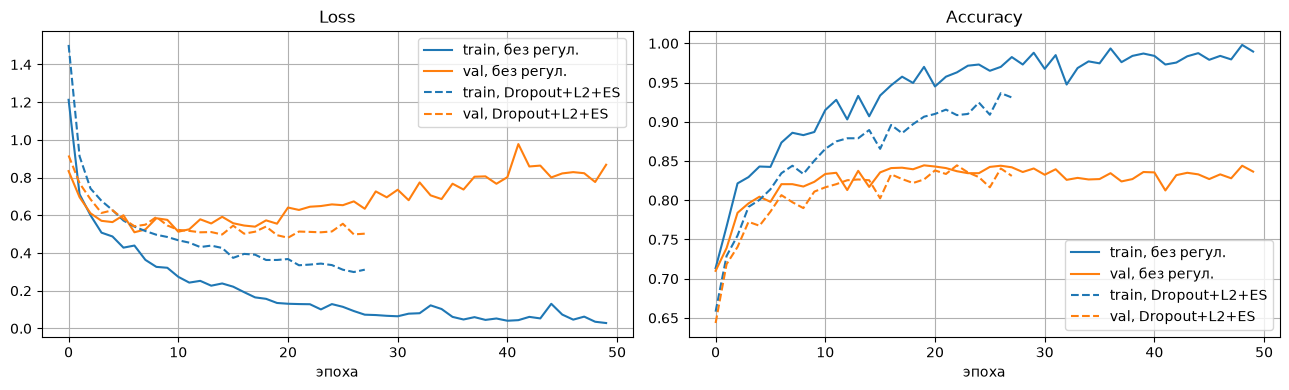

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(overfit_history['train_loss'], label='train, без регул.', color='C0')
ax[0].plot(overfit_history['val_loss'], label='val, без регул.', color='C1')
ax[0].plot(regularized_history['train_loss'], label='train, Dropout+L2+ES',
           color='C0', linestyle='--')
ax[0].plot(regularized_history['val_loss'], label='val, Dropout+L2+ES',
           color='C1', linestyle='--')
ax[0].set_title('Loss')

ax[1].plot(overfit_history['train_acc'], label='train, без регул.', color='C0')
ax[1].plot(overfit_history['val_acc'], label='val, без регул.', color='C1')
ax[1].plot(regularized_history['train_acc'], label='train, Dropout+L2+ES',
           color='C0', linestyle='--')
ax[1].plot(regularized_history['val_acc'], label='val, Dropout+L2+ES',
           color='C1', linestyle='--')
ax[1].set_title('Accuracy')

for a in ax:
    a.set_xlabel('эпоха')
    a.legend()
    a.grid(True)
plt.tight_layout()
plt.show()

**Вывод:** у сети высокой ёмкости train loss продолжает уменьшаться,
когда validation loss уже перестаёт улучшаться — это признак переобучения.
`Dropout(0.5)` случайно отключает признаки во время обучения, `weight_decay`
штрафует большие веса, а ручная ранняя остановка возвращает состояние модели с
минимальной validation loss. Вместе эти методы уменьшают разрыв между train и
validation и не тратят время на заведомо ухудшающиеся эпохи.